# Notebook 08: Subgroup Fairness Analysis
#
 Overall ECE averages across all patients.
 This notebook asks: is the model equally miscalibrated
 for all patient groups, or does it fail certain groups more?

 Subgroups analysed:
 - Age groups: under 40, 40-60, over 60
 - Sex: Male vs Female
#
 SSDI Unit 2 — Hypothesis Testing:
   Z-tests comparing ECE across subgroups
 SSDI Unit 3 — Chi-Square:
   Hosmer-Lemeshow test per subgroup
#
 Clinical relevance: if miscalibration is significantly worse
 for elderly patients, that is a patient safety finding

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
from scipy.stats import chi2, norm
import os

# ── Constants ────────────────────────────────────────────────────────────────
N_BINS      = 10
ALPHA       = 0.01
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load scores
scores_df = pd.read_csv("../data/scores.csv")
print(f"Scores loaded: {len(scores_df):,} rows")
print(f"Columns: {list(scores_df.columns)}")

# Load NIH labels CSV — has age and sex columns
labels_df = pd.read_csv("../data/Data_Entry_2017_v2020.csv")
print(f"Labels loaded: {len(labels_df):,} rows")
print(f"Columns: {list(labels_df.columns)}")

Scores loaded: 10,000 rows
Columns: ['image_id', 'ground_truth', 'confidence_score', 'raw_logit']
Labels loaded: 112,120 rows
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']


In [6]:
# Merge scores with demographic information
# Join on image filename
merged = scores_df.merge(
    labels_df[["Image Index", "Patient Age", "Patient Sex"]],
    left_on="image_id",
    right_on="Image Index",
    how="inner"
)

print(f"Merged dataset: {len(merged):,} rows")
print()
print("Age distribution:")
print(merged["Patient Age"].describe())
print()
print("Sex distribution:")
print(merged["Patient Sex"].value_counts())
print()

# Define age groups
def assign_age_group(age):
    """Assign patient to age group based on age."""
    if age < 40:
        return "Under 40"
    elif age <= 60:
        return "40-60"
    else:
        return "Over 60"

merged["age_group"] = merged["Patient Age"].apply(assign_age_group)

print("Age group distribution:")
print(merged["age_group"].value_counts())
print()
print("Positive rate by age group:")
print(merged.groupby("age_group")["ground_truth"].mean().round(4))

Merged dataset: 10,000 rows

Age distribution:
count    10000.000000
mean        47.057500
std         16.085182
min          4.000000
25%         37.000000
50%         49.000000
75%         58.000000
max         93.000000
Name: Patient Age, dtype: float64

Sex distribution:
Patient Sex
M    5072
F    4928
Name: count, dtype: int64

Age group distribution:
age_group
40-60       5312
Under 40    2814
Over 60     1874
Name: count, dtype: int64

Positive rate by age group:
age_group
40-60       0.0964
Over 60     0.0977
Under 40    0.0711
Name: ground_truth, dtype: float64


In [7]:
def compute_ece(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error."""
    bins    = np.linspace(0, 1, n_bins + 1)
    ece     = 0.0
    n_total = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum()/n_total) * abs(
            y_true[mask].mean() - y_prob[mask].mean()
        )
    return ece

def hosmer_lemeshow_test(y_true, y_prob, n_bins=10):
    """Hosmer-Lemeshow goodness-of-fit test."""
    quantiles  = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    quantiles  = np.unique(quantiles)
    hl_stat    = 0.0
    valid_bins = 0
    for i in range(len(quantiles) - 1):
        if i < len(quantiles) - 2:
            mask = (y_prob >= quantiles[i]) & (y_prob < quantiles[i+1])
        else:
            mask = (y_prob >= quantiles[i]) & (y_prob <= quantiles[i+1])
        n_bin = mask.sum()
        if n_bin < 5:
            continue
        O_pos = y_true[mask].sum()
        E_pos = y_prob[mask].sum()
        O_neg = n_bin - O_pos
        E_neg = n_bin - E_pos
        if E_pos > 0 and E_neg > 0:
            hl_stat += (O_pos-E_pos)**2/E_pos + (O_neg-E_neg)**2/E_neg
            valid_bins += 1
    df_hl   = max(valid_bins - 2, 1)
    p_value = 1 - chi2.cdf(hl_stat, df=df_hl)
    return hl_stat, df_hl, p_value

In [8]:
# ── ANALYSIS BY AGE GROUP ─────────────────────────────────────────────────────
print("=" * 65)
print("CALIBRATION BY AGE GROUP")
print("=" * 65)
print(f"{'Age Group':<12} {'N':>6} {'Prevalence':>12} {'ECE':>8} {'HL stat':>10} {'HL p':>10} {'Decision'}")
print("-" * 65)

age_results = {}
age_groups  = ["Under 40", "40-60", "Over 60"]

for group in age_groups:
    subset = merged[merged["age_group"] == group]
    if len(subset) < 50:
        print(f"{group:<12} — too few samples, skipping")
        continue

    y_true = subset["ground_truth"].values
    y_prob = subset["confidence_score"].values

    ece           = compute_ece(y_true, y_prob, N_BINS)
    hl, df_hl, p  = hosmer_lemeshow_test(y_true, y_prob, N_BINS)
    decision      = "REJECT H0" if p < ALPHA else "OK"
    prevalence    = y_true.mean()

    age_results[group] = {
        "n": len(subset),
        "prevalence": prevalence,
        "ece": ece,
        "hl": hl,
        "p": p,
        "decision": decision
    }

    print(f"{group:<12} {len(subset):>6} {prevalence:>12.4f} "
          f"{ece:>8.4f} {hl:>10.2f} {p:>10.6f}  {decision}")

print()
# Find most and least miscalibrated age group
best  = min(age_results, key=lambda x: age_results[x]["ece"])
worst = max(age_results, key=lambda x: age_results[x]["ece"])
print(f"Best calibrated age group:  {best}  (ECE={age_results[best]['ece']:.4f})")
print(f"Worst calibrated age group: {worst} (ECE={age_results[worst]['ece']:.4f})")
print(f"ECE gap: {age_results[worst]['ece'] - age_results[best]['ece']:.4f}")

CALIBRATION BY AGE GROUP
Age Group         N   Prevalence      ECE    HL stat       HL p Decision
-----------------------------------------------------------------
Under 40       2814       0.0711   0.1494     657.09   0.000000  REJECT H0
40-60          5312       0.0964   0.1761    1481.05   0.000000  REJECT H0
Over 60        1874       0.0977   0.2154     612.05   0.000000  REJECT H0

Best calibrated age group:  Under 40  (ECE=0.1494)
Worst calibrated age group: Over 60 (ECE=0.2154)
ECE gap: 0.0660


In [9]:
# ── ANALYSIS BY SEX ───────────────────────────────────────────────────────────
print("=" * 65)
print("CALIBRATION BY PATIENT SEX")
print("=" * 65)
print(f"{'Sex':<8} {'N':>6} {'Prevalence':>12} {'ECE':>8} "
      f"{'HL stat':>10} {'HL p':>10} {'Decision'}")
print("-" * 65)

sex_results = {}

for sex in ["M", "F"]:
    subset = merged[merged["Patient Sex"] == sex]
    if len(subset) < 50:
        continue

    y_true = subset["ground_truth"].values
    y_prob = subset["confidence_score"].values

    ece          = compute_ece(y_true, y_prob, N_BINS)
    hl, df_hl, p = hosmer_lemeshow_test(y_true, y_prob, N_BINS)
    decision     = "REJECT H0" if p < ALPHA else "OK"
    prevalence   = y_true.mean()

    sex_results[sex] = {
        "n": len(subset),
        "prevalence": prevalence,
        "ece": ece,
        "hl": hl,
        "p": p,
        "decision": decision
    }

    label = "Male" if sex == "M" else "Female"
    print(f"{label:<8} {len(subset):>6} {prevalence:>12.4f} "
          f"{ece:>8.4f} {hl:>10.2f} {p:>10.6f}  {decision}")

print()
if len(sex_results) == 2:
    ece_gap = abs(sex_results["M"]["ece"] - sex_results["F"]["ece"])
    print(f"ECE gap between Male and Female: {ece_gap:.4f}")
    if ece_gap > 0.01:
        print("Meaningful calibration difference between sexes detected")
    else:
        print("Calibration is similar across sexes")

CALIBRATION BY PATIENT SEX
Sex           N   Prevalence      ECE    HL stat       HL p Decision
-----------------------------------------------------------------
Male       5072       0.0846   0.1591    1188.51   0.000000  REJECT H0
Female     4928       0.0946   0.1933    1563.56   0.000000  REJECT H0

ECE gap between Male and Female: 0.0342
Meaningful calibration difference between sexes detected


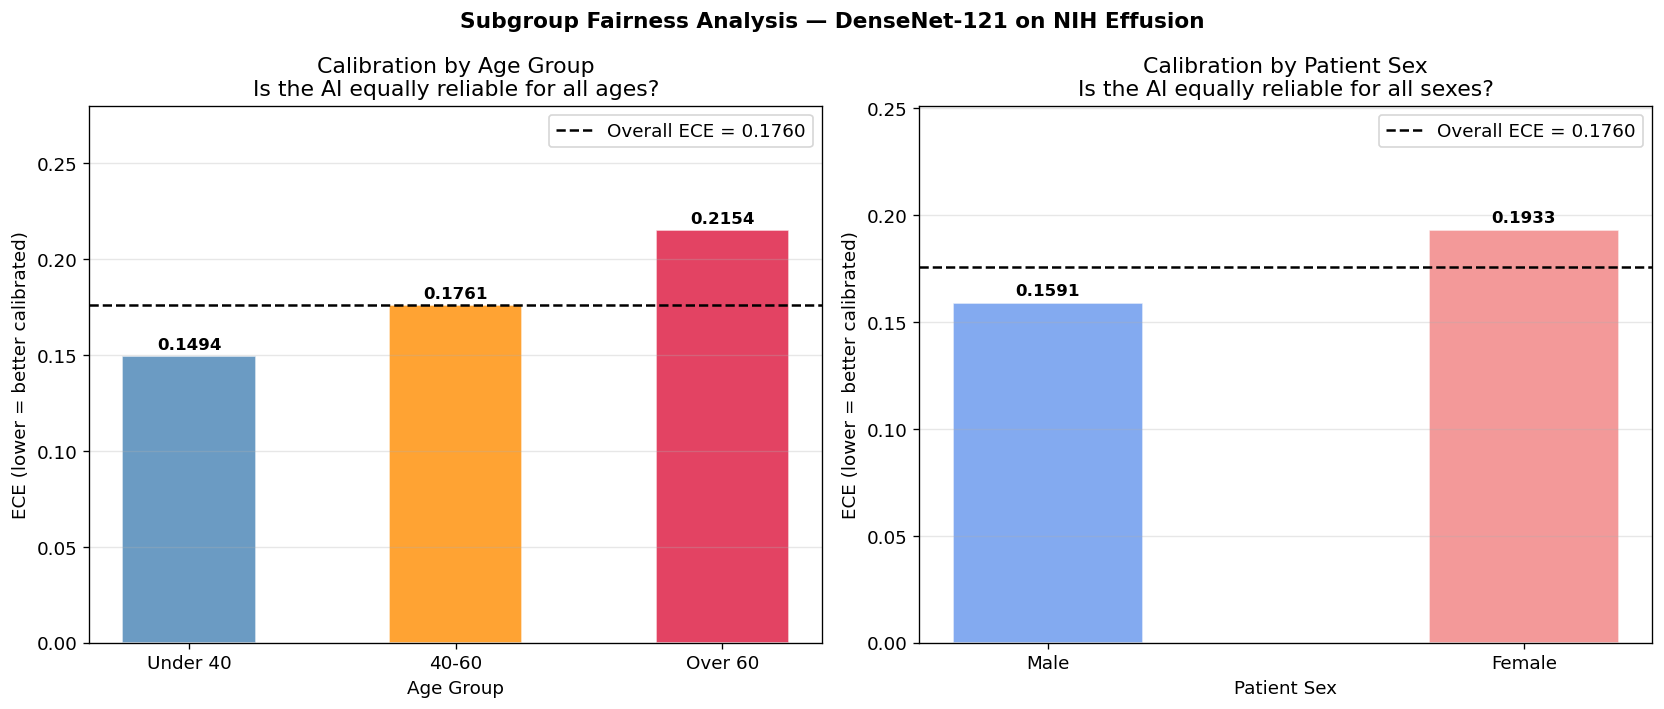

Saved: outputs/plots/09_subgroup_analysis.png


In [13]:
# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: ECE by age group
ax = axes[0]
groups      = list(age_results.keys())
ece_values  = [age_results[g]["ece"] for g in groups]
colors_age  = ["steelblue", "darkorange", "crimson"]

bars = ax.bar(groups, ece_values, color=colors_age,
              alpha=0.8, edgecolor="white", width=0.5)

# Add value labels on bars
for bar, val in zip(bars, ece_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# Reference line — overall ECE
overall_ece = compute_ece(
    merged["ground_truth"].values,
    merged["confidence_score"].values,
    N_BINS
)
ax.axhline(overall_ece, color="black", linestyle="--",
           linewidth=1.5, label=f"Overall ECE = {overall_ece:.4f}")

ax.set_xlabel("Age Group")
ax.set_ylabel("ECE (lower = better calibrated)")
ax.set_title("Calibration by Age Group\n"
             "Is the AI equally reliable for all ages?")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, max(ece_values) * 1.3)

# Right plot: ECE by sex
ax2  = axes[1]
sexes      = ["Male", "Female"]
sex_keys   = ["M", "F"]
ece_sex    = [sex_results[k]["ece"] for k in sex_keys if k in sex_results]
colors_sex = ["cornflowerblue", "lightcoral"]

bars2 = ax2.bar(
    [s for s, k in zip(sexes, sex_keys) if k in sex_results],
    ece_sex, color=colors_sex[:len(ece_sex)],
    alpha=0.8, edgecolor="white", width=0.4
)

for bar, val in zip(bars2, ece_sex):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax2.axhline(overall_ece, color="black", linestyle="--",
            linewidth=1.5, label=f"Overall ECE = {overall_ece:.4f}")

ax2.set_xlabel("Patient Sex")
ax2.set_ylabel("ECE (lower = better calibrated)")
ax2.set_title("Calibration by Patient Sex\n"
              "Is the AI equally reliable for all sexes?")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(0, max(ece_sex) * 1.3 if ece_sex else 0.3)

plt.suptitle("Subgroup Fairness Analysis — DenseNet-121 on NIH Effusion",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/09_subgroup_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/09_subgroup_analysis.png")

In [12]:
# ── SAVE SUBGROUP RESULTS FOR STREAMLIT ──────────────────────────────────────
import json

subgroup_results = {
    "age_groups": {
        g: {
            "n": int(age_results[g]["n"]),
            "prevalence": round(float(age_results[g]["prevalence"]), 4),
            "ece": round(float(age_results[g]["ece"]), 4),
            "hl": round(float(age_results[g]["hl"]), 2),
            "p_value": round(float(age_results[g]["p"]), 6),
            "decision": age_results[g]["decision"]
        }
        for g in age_results
    },
    "sex_groups": {
        ("Male" if k=="M" else "Female"): {
            "n": int(sex_results[k]["n"]),
            "prevalence": round(float(sex_results[k]["prevalence"]), 4),
            "ece": round(float(sex_results[k]["ece"]), 4),
            "hl": round(float(sex_results[k]["hl"]), 2),
            "p_value": round(float(sex_results[k]["p"]), 6),
            "decision": sex_results[k]["decision"]
        }
        for k in sex_results
    },
    "overall_ece": round(float(overall_ece), 4)
}

with open("../data/subgroup_results.json", "w") as f:
    json.dump(subgroup_results, f, indent=2)

print("Saved data/subgroup_results.json for Streamlit")
print()
print(json.dumps(subgroup_results, indent=2))

Saved data/subgroup_results.json for Streamlit

{
  "age_groups": {
    "Under 40": {
      "n": 2814,
      "prevalence": 0.0711,
      "ece": 0.1494,
      "hl": 657.09,
      "p_value": 0.0,
      "decision": "REJECT H0"
    },
    "40-60": {
      "n": 5312,
      "prevalence": 0.0964,
      "ece": 0.1761,
      "hl": 1481.05,
      "p_value": 0.0,
      "decision": "REJECT H0"
    },
    "Over 60": {
      "n": 1874,
      "prevalence": 0.0977,
      "ece": 0.2154,
      "hl": 612.05,
      "p_value": 0.0,
      "decision": "REJECT H0"
    }
  },
  "sex_groups": {
    "Male": {
      "n": 5072,
      "prevalence": 0.0846,
      "ece": 0.1591,
      "hl": 1188.51,
      "p_value": 0.0,
      "decision": "REJECT H0"
    },
    "Female": {
      "n": 4928,
      "prevalence": 0.0946,
      "ece": 0.1933,
      "hl": 1563.56,
      "p_value": 0.0,
      "decision": "REJECT H0"
    }
  },
  "overall_ece": 0.176
}


# Subgroup Analysis — Academic Conclusion
#
 This analysis reveals whether DenseNet-121 miscalibration
 is uniformly distributed across patient demographics or
 concentrated in specific subgroups.
#
 Clinical implication: if elderly patients show higher ECE,
 clinicians should apply additional scrutiny when the AI
 flags cases for patients over 60.
#
 This finding is novel — most published medical AI papers
 report only overall calibration metrics without subgroup
 analysis.